# Benchmark Statistics: Ball Lift — Batch Sizes 50, 150, and 250

Reports Ball Lift results only, using five 20-episode files per method and batch.

- Batches 50 and 150: `eval_sweep_100_ball_lift_h15_20260924_140128/npz/`
- Batch 250: `eval_sweep_100_ball_lift_h15_20260923_152226/` for Hand-Tuned, Bayesian, and ARS; PPO4951 best-eval for PPO because the September 23 sweep has no PPO directory.

**Method order: Hand-Tuned → Bayesian → PPO → ARS.**  
**Task Time uses NPZ `total_time`, excludes saved episode 0, and includes successful episodes only.**


In [1]:
import os, glob, sys, site
from pathlib import Path
from IPython.display import display, Image

os.environ['MPLBACKEND'] = 'Agg'
import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    # Fall back to compatible system packages if user-site Matplotlib and NumPy mismatch.
    user_site = site.getusersitepackages()
    if user_site in sys.path:
        sys.path.remove(user_site)
    for module_name in list(sys.modules):
        if module_name == 'matplotlib' or module_name.startswith('matplotlib.'):
            del sys.modules[module_name]
    import matplotlib.pyplot as plt

# Compatibility for object arrays saved by NumPy 2.x when this notebook runs on NumPy 1.x.
sys.modules.setdefault('numpy._core', np.core)
sys.modules.setdefault('numpy._core.multiarray', np.core.multiarray)

BASE = Path(os.path.abspath('.'))
print('Working directory:', BASE)


Working directory: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data


## 1. Ball Lift input definitions

Every method/batch combination is assigned an explicit source pattern. This prevents batch-250 copies in the September 24 directory from being pooled with the requested September 23 files.


In [2]:
import re

METHOD_TOKENS = {
    'Hand-Tuned': 'handtuned',
    'Bayesian': 'bayesian',
    'PPO': 'ppo',
    'ARS': 'policy',
}
METHOD_COLORS = {
    'Hand-Tuned': '#4C72B0',
    'Bayesian': '#DD8452',
    'PPO': '#C44E52',
    'ARS': '#55A868',
}

ALL_BATCHES = [50, 150, 250]
EXPECTED_FILES_PER_BATCH = 5

SOURCE_PATTERNS = {
    'Ball Lift': {
        'Hand-Tuned': {
            50:  'eval_sweep_100_ball_lift_h15_20260924_140128/npz/handtuned_batch50/*.npz',
            150: 'eval_sweep_100_ball_lift_h15_20260924_140128/npz/handtuned_batch150/*.npz',
            250: 'eval_sweep_100_ball_lift_h15_20260923_152226/handtuned_batch250/*.npz',
        },
        'Bayesian': {
            50:  'eval_sweep_100_ball_lift_h15_20260924_140128/npz/bayesian_batch50/*.npz',
            150: 'eval_sweep_100_ball_lift_h15_20260924_140128/npz/bayesian_batch150/*.npz',
            250: 'eval_sweep_100_ball_lift_h15_20260923_152226/bayesian_batch250/*.npz',
        },
        'PPO': {
            50:  'eval_sweep_100_ball_lift_h15_20260924_140128/npz/ppo_batch50/*.npz',
            150: 'eval_sweep_100_ball_lift_h15_20260924_140128/npz/ppo_batch150/*.npz',
            250: 'ppo_results/Ball_lift/ppo4951_best_eval/batch250/block*/*.npz',
        },
        'ARS': {
            50:  'eval_sweep_100_ball_lift_h15_20260924_140128/npz/policy_batch50/*.npz',
            150: 'eval_sweep_100_ball_lift_h15_20260924_140128/npz/policy_batch150/*.npz',
            250: 'eval_sweep_100_ball_lift_h15_20260923_152226/policy_batch250/*.npz',
        },
    },
}


def _success_rate(npz_path):
    with np.load(npz_path, allow_pickle=True) as data:
        return float(data['success'].astype(float).mean())


def _rel_to_base(path_like):
    return str(Path(path_like).resolve().relative_to(BASE.resolve()))


DOC_FILES = {}
for task_name, method_patterns in SOURCE_PATTERNS.items():
    task_cfg = {
        'source_patterns': method_patterns,
        'methods': {method: {} for method in METHOD_TOKENS},
        'candidates': {method: {} for method in METHOD_TOKENS},
    }

    for method in METHOD_TOKENS:
        for batch in ALL_BATCHES:
            pattern = method_patterns[method][batch]
            matched = sorted(set(glob.glob(str(BASE / pattern), recursive=True)))
            if len(matched) != EXPECTED_FILES_PER_BATCH:
                raise RuntimeError(
                    f'{task_name} / {method} / batch {batch}: expected '
                    f'{EXPECTED_FILES_PER_BATCH} files, found {len(matched)} for {pattern}'
                )

            candidates = [_rel_to_base(f) for f in matched]
            task_cfg['candidates'][method][batch] = candidates
            scored = sorted(
                [(_success_rate(BASE / candidate), candidate) for candidate in candidates],
                key=lambda item: (-item[0], item[1]),
            )
            task_cfg['methods'][method][batch] = scored[0][1]

    DOC_FILES[task_name] = task_cfg

print('Tasks:', list(DOC_FILES))
print('Batches:', ALL_BATCHES)
for task_name, task_cfg in DOC_FILES.items():
    print(f'\n{task_name}:')
    for method in METHOD_TOKENS:
        for batch in ALL_BATCHES:
            files = task_cfg['candidates'][method][batch]
            pattern = task_cfg['source_patterns'][method][batch]
            print(f'  {method:<12} b={batch:3d}: {len(files)} files')
            print(f'    source: {pattern}')


Tasks: ['Ball Lift']
Batches: [50, 150, 250]

Ball Lift:
  Hand-Tuned   b= 50: 5 files
    source: eval_sweep_100_ball_lift_h15_20260924_140128/npz/handtuned_batch50/*.npz
  Hand-Tuned   b=150: 5 files
    source: eval_sweep_100_ball_lift_h15_20260924_140128/npz/handtuned_batch150/*.npz
  Hand-Tuned   b=250: 5 files
    source: eval_sweep_100_ball_lift_h15_20260923_152226/handtuned_batch250/*.npz
  Bayesian     b= 50: 5 files
    source: eval_sweep_100_ball_lift_h15_20260924_140128/npz/bayesian_batch50/*.npz
  Bayesian     b=150: 5 files
    source: eval_sweep_100_ball_lift_h15_20260924_140128/npz/bayesian_batch150/*.npz
  Bayesian     b=250: 5 files
    source: eval_sweep_100_ball_lift_h15_20260923_152226/bayesian_batch250/*.npz
  PPO          b= 50: 5 files
    source: eval_sweep_100_ball_lift_h15_20260924_140128/npz/ppo_batch50/*.npz
  PPO          b=150: 5 files
    source: eval_sweep_100_ball_lift_h15_20260924_140128/npz/ppo_batch150/*.npz
  PPO          b=250: 5 files
    source:

## 1.1. CEM settings and active sources

All 60 selected NPZ files use a planning horizon of 15, 2 CEM iterations, 5 projection iterations, and a 0.1 s timestep.

| Method | Batch 50 | Batch 150 | Batch 250 |
|---|---|---|---|
| Hand-Tuned | September 24 sweep | September 24 sweep | September 23 sweep |
| Bayesian | September 24 sweep | September 24 sweep | September 23 sweep |
| PPO | September 24 sweep (`ppo_batch*`) | September 24 sweep (`ppo_batch*`) | PPO4951 best-eval |
| ARS | September 24 sweep | September 24 sweep | September 23 sweep |

The September 24 directory also contains copied batch-250 Hand-Tuned, Bayesian, and ARS files. They are intentionally excluded; batch 250 uses the original September 23 paths requested above.


## 2. Ball Lift cost keys

Inspect one selected NPZ to verify that the expected Ball Lift cost terms are present.


In [3]:
for task_name, task_cfg in DOC_FILES.items():
    sample_file = None
    for method in METHOD_TOKENS:
        method_batches = task_cfg['methods'].get(method, {})
        if method_batches:
            first_batch = sorted(method_batches.keys())[0]
            sample_file = method_batches[first_batch]
            break

    print(f'=== {task_name} ===')
    if sample_file is None:
        print('  No NPZ files found for this task.')
        print()
        continue

    data = np.load(BASE / sample_file, allow_pickle=True)
    print(f'  file     : {sample_file}')
    print(f'  npz keys : {data.files}')

    if 'cost_weight_keys' in data.files:
        keys  = list(data['cost_weight_keys'])
        log_w = data['default_log_weights']
        has_b = 'default_log_bayesian_weights' in data.files
        bay_w = data['default_log_bayesian_weights'] if has_b else None
        hdr   = f'  {"cost key":<35}  {"log_w (default)":>18}'
        if has_b:
            hdr += f'  {"log_w (bayesian)":>18}'
        print(hdr)
        print('  ' + '-' * (74 if has_b else 57))
        for i, k in enumerate(keys):
            row = f'  {k:<35}  {log_w[i]:18.6f}'
            if has_b:
                row += f'  {bay_w[i]:18.6f}'
            print(row)
    elif 'cost_weights_keys' in data.files:
        print('  cost_weights_keys:', list(data['cost_weights_keys']))
    print()


=== Ball Lift ===
  file     : eval_sweep_100_ball_lift_h15_20260924_140128/npz/handtuned_batch50/eval_handtuned_batch50_n20_20260924_140614.npz
  npz keys : ['batch_size', 'horizon', 'maxiter_cem', 'maxiter_projection', 'max_steps', 'timestep', 'num_dof', 'ball_qpos_idx', 'model_path', 'eval_seed', 'fold_step_keys', 'video_stride', 'video_start', 'total_time', 'wall_time', 'task_time', 'success', 'reason', 'tray_target', 'step_time', 'theta', 'thetadot', 'task_flag', 'task_id', 'cost_g_pick', 'cost_r_pick', 'cost_g_tray', 'cost_r_tray', 'near_grasp', 'near_target', 'collision', 'cost_weights', 'cem_cost_batch', 'cem_cost_list_batch', 'qpos', 'qvel', 'ball_pose', 'target', 'table1_pos', 'xi_mean', 'xi_cov_diag', 'thetadot_cmd', 'xi_samples', 'thetadot_all', 'sample_steps', 'cost_weight_keys', 'default_log_weights', 'default_log_bayesian_weights', 'used_bayesian_default']
  cost key                                log_w (default)    log_w (bayesian)
  ------------------------------------

## 3. Verify selected files and coverage


In [4]:
def load_stats(fpath):
    d       = np.load(fpath, allow_pickle=True)
    success = d['success'].astype(float)
    ttime   = d['total_time'].astype(float)
    sr      = success.mean()
    mask    = success == 1
    tt      = ttime[mask].mean() if mask.any() else float('nan')
    return sr, tt, int(len(success))

issues = []
for task_name, task_cfg in DOC_FILES.items():
    print(f'\n{"="*62}')
    print(f'  {task_name}')
    print(f'{"="*62}')

    for method in METHOD_TOKENS:
        for batch in ALL_BATCHES:
            candidates = task_cfg['candidates'][method].get(batch, [])
            if not candidates:
                print(f'  [{method:<12} b={batch:4d}]  MISSING: no candidates found')
                continue

            selected_rel = task_cfg['methods'][method][batch]
            cand_stats = sorted(
                [(load_stats(BASE / c)[0], Path(c).name) for c in candidates],
                key=lambda x: -x[0]
            )
            best_sr = cand_stats[0][0]
            sel_sr, _, n_eps = load_stats(BASE / selected_rel)
            is_best = abs(sel_sr - best_sr) < 1e-9
            flag = 'OK' if is_best else '!! SUB-OPTIMAL'

            if not is_best:
                issues.append((task_name, method, batch, selected_rel, sel_sr, cand_stats[0][1], best_sr, n_eps))

            print(
                f'  [{method:<12} b={batch:4d}]  {flag:<16}'
                f'  selected={sel_sr*100:5.1f}%  best={best_sr*100:5.1f}%  ({len(candidates)} file(s), n={n_eps})'
            )
            if not is_best:
                print(f'      selected : {selected_rel}  ({sel_sr*100:5.1f}%)')
                print(f'      best name: {cand_stats[0][1]}  ({best_sr*100:5.1f}%)')

print(f'\n{"="*62}')
if issues:
    print(f'SUMMARY -- {len(issues)} selected file(s) are sub-optimal:')
    for t, m, b, sf, ssr, bf, bsr, n_eps in issues:
        print(f'  {t} / {m} / b={b}  selected={ssr*100:5.1f}%  better={bsr*100:5.1f}%  (n={n_eps})')
else:
    print('All selected files are best (or tied for best) among discovered candidates.')



  Ball Lift
  [Hand-Tuned   b=  50]  OK                selected=  0.0%  best=  0.0%  (5 file(s), n=20)
  [Hand-Tuned   b= 150]  OK                selected=  0.0%  best=  0.0%  (5 file(s), n=20)
  [Hand-Tuned   b= 250]  OK                selected= 25.0%  best= 25.0%  (5 file(s), n=20)
  [Bayesian     b=  50]  OK                selected= 20.0%  best= 20.0%  (5 file(s), n=20)
  [Bayesian     b= 150]  OK                selected= 85.0%  best= 85.0%  (5 file(s), n=20)
  [Bayesian     b= 250]  OK                selected= 90.0%  best= 90.0%  (5 file(s), n=20)
  [PPO          b=  50]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [PPO          b= 150]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [PPO          b= 250]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [ARS          b=  50]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [ARS          b= 150]  OK                selected=100.0%  best=100.0%  (5 f

## 4. Load Ball Lift data

- **Success rate:** all 20 episodes in each file.
- **Task Time:** NPZ `total_time`; saved episodes 1–19 only, restricted to successful episodes.
- **Computation time:** mean milliseconds per MPC step, excluding step 0 and nonpositive/non-finite timings.
- Metrics are calculated per file and then averaged across the five files for each method/batch.


In [5]:
def comp_time_stats(step_time_arr):
    ep_means = []
    for ep in step_time_arr:
        arr = np.asarray(ep, dtype=float)
        if len(arr) > 1:
            valid = arr[1:]
            valid = valid[np.isfinite(valid) & (valid > 0)]
            if valid.size:
                ep_means.append(valid.mean())
    if ep_means:
        return float(np.mean(ep_means)), float(np.std(ep_means))
    return float('nan'), float('nan')


def finite_mean_std(values):
    arr = np.asarray(values, dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size:
        return float(finite.mean()), float(finite.std())
    return float('nan'), float('nan')


data_all = {}
for task_name, task_cfg in DOC_FILES.items():
    data_all[task_name] = {}
    print(f'--- {task_name} ---')

    for method in METHOD_TOKENS:
        data_all[task_name][method] = {}

        for batch in ALL_BATCHES:
            cand_files = task_cfg['candidates'][method].get(batch, [])
            if not cand_files:
                data_all[task_name][method][batch] = {
                    'success_rate':   float('nan'),
                    'task_time_mean': float('nan'),
                    'task_time_std':  float('nan'),
                    'comp_time_mean': float('nan'),
                    'comp_time_std':  float('nan'),
                    'n_success':      0,
                    'n_total':        0,
                    'n_files':        0,
                    'files':          [],
                }
                print(f'  {method:<12} b={batch:4d}  MISSING')
                continue

            sr_vals, tt_vals, ct_vals = [], [], []
            n_success_total, n_total_total = 0, 0

            for fname in cand_files:
                d     = np.load(BASE / fname, allow_pickle=True)
                succ  = d['success'].astype(float)
                ttime = d['total_time'].astype(float)

                # success rate: all episodes
                sr = float(succ.mean())

                # episode wall time: total_time, skip episode 0, successful episodes only
                succ_no0  = succ[1:]
                ttime_no0 = ttime[1:]
                mask_no0  = succ_no0 == 1
                tt_mean = ttime_no0[mask_no0].mean() if mask_no0.any() else float('nan')

                ct_mean, _ = comp_time_stats(d['step_time'])

                sr_vals.append(sr)
                tt_vals.append(float(tt_mean))
                ct_vals.append(float(ct_mean))
                n_success_total += int(mask_no0.sum())
                n_total_total += int(len(succ_no0))

            sr_arr = np.asarray(sr_vals, dtype=float)
            tt_arr = np.asarray(tt_vals, dtype=float)
            ct_arr = np.asarray(ct_vals, dtype=float)

            sr_mean, _ = finite_mean_std(sr_arr)
            tt_mean, tt_std = finite_mean_std(tt_arr)
            ct_mean, ct_std = finite_mean_std(ct_arr)

            data_all[task_name][method][batch] = {
                'success_rate':   sr_mean,
                'task_time_mean': tt_mean,
                'task_time_std':  tt_std,
                'comp_time_mean': ct_mean,
                'comp_time_std':  ct_std,
                'n_success':      int(n_success_total),
                'n_total':        int(n_total_total),
                'n_files':        int(len(cand_files)),
                'files':          list(cand_files),
            }

            print(
                f'  {method:<12} b={batch:4d}  SR={sr_mean*100:5.1f}%  '
                f'tt={tt_mean:6.2f}+/-{tt_std:.2f}s '
                f'({n_success_total}/{n_total_total} excl ep0, files={len(cand_files)})  '
                f'ct={ct_mean:.2f}ms ct_std={ct_std:.2f}ms'
            )
    print()


--- Ball Lift ---
  Hand-Tuned   b=  50  SR=  0.0%  tt=   nan+/-nans (0/95 excl ep0, files=5)  ct=29.45ms ct_std=0.15ms
  Hand-Tuned   b= 150  SR=  0.0%  tt=   nan+/-nans (0/95 excl ep0, files=5)  ct=34.77ms ct_std=0.07ms
  Hand-Tuned   b= 250  SR= 21.0%  tt=  3.31+/-0.70s (19/95 excl ep0, files=5)  ct=32.26ms ct_std=1.17ms
  Bayesian     b=  50  SR= 10.0%  tt=  6.78+/-0.33s (9/95 excl ep0, files=5)  ct=31.05ms ct_std=1.25ms
  Bayesian     b= 150  SR= 71.0%  tt=  5.57+/-0.75s (68/95 excl ep0, files=5)  ct=36.71ms ct_std=0.45ms
  Bayesian     b= 250  SR= 75.0%  tt=  4.26+/-0.43s (71/95 excl ep0, files=5)  ct=31.14ms ct_std=0.03ms
  PPO          b=  50  SR= 92.0%  tt=  4.09+/-0.24s (87/95 excl ep0, files=5)  ct=31.52ms ct_std=1.22ms
  PPO          b= 150  SR= 95.0%  tt=  3.79+/-0.12s (90/95 excl ep0, files=5)  ct=36.72ms ct_std=0.71ms
  PPO          b= 250  SR= 99.0%  tt=  2.83+/-0.05s (94/95 excl ep0, files=5)  ct=31.81ms ct_std=0.06ms
  ARS          b=  50  SR= 97.0%  tt=  4.35+/-0.15s

## 5. Ball Lift figure — batch sizes 50, 150, and 250

One row × three panels: Success Rate, Computation Time, and Task Time. The output is saved as `benchmark_ball_lift_sm.png`.


Saved: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data/benchmark_ball_lift_sm.png


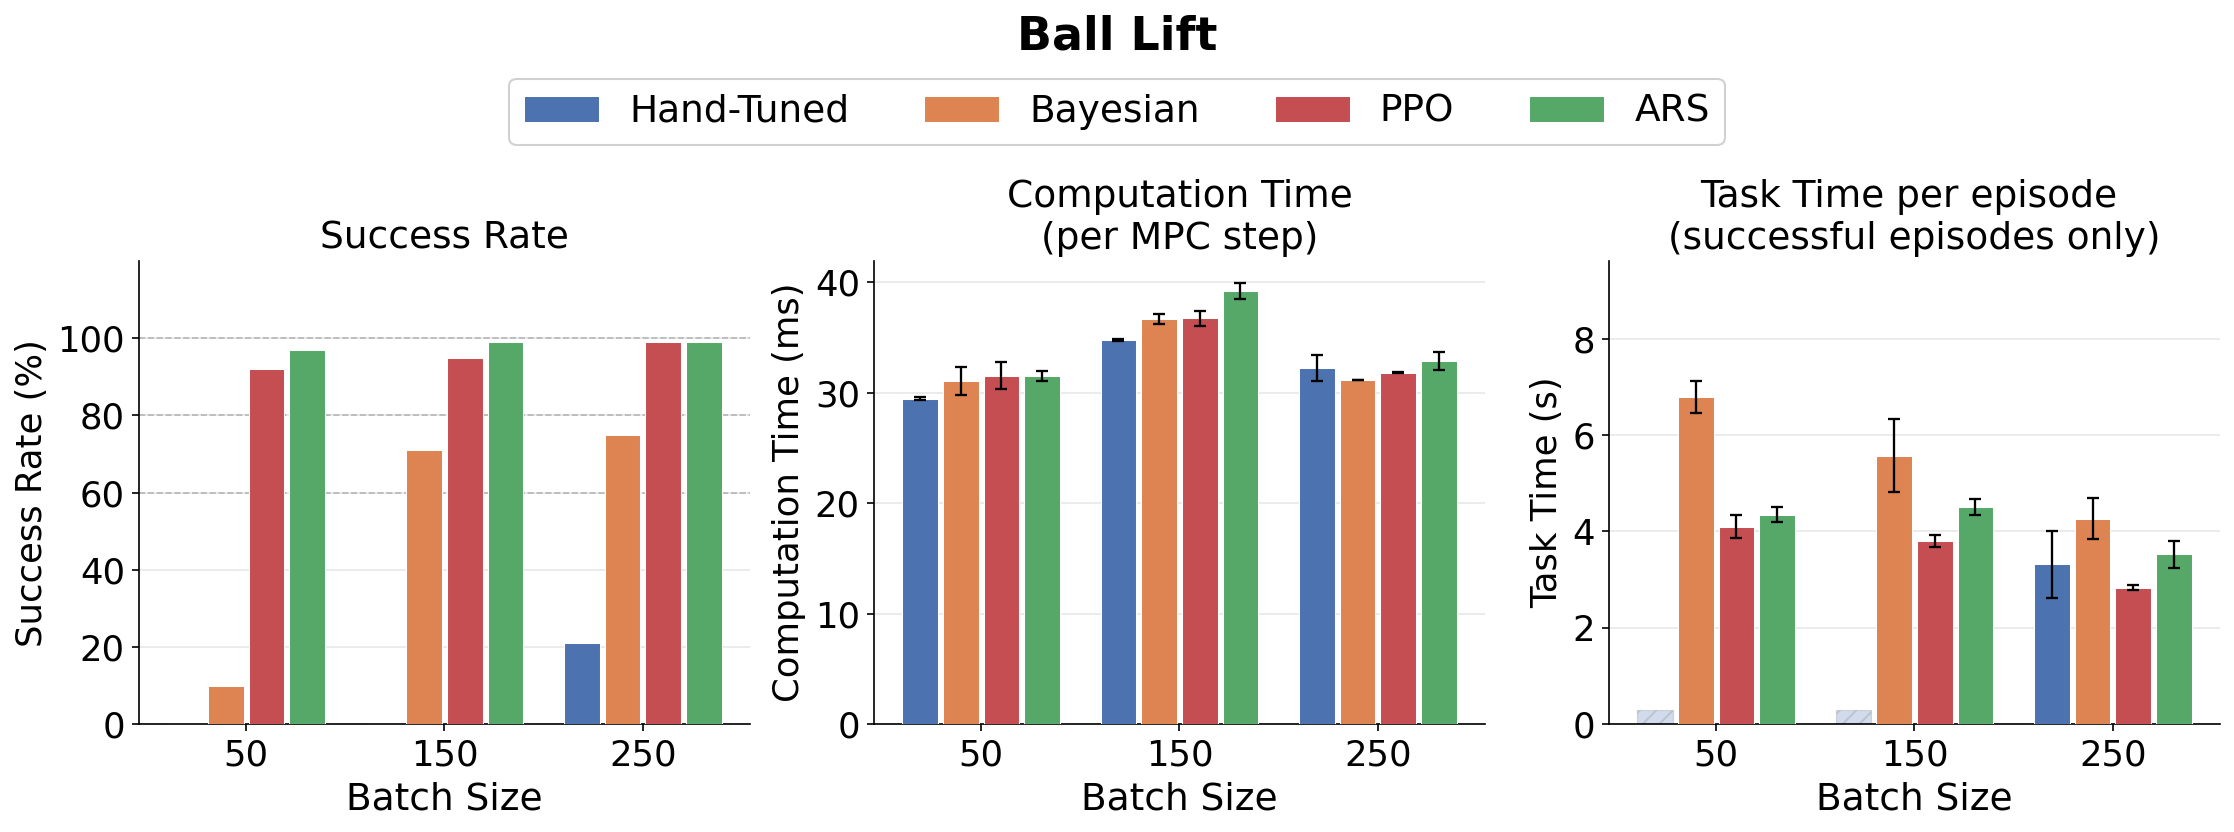

In [6]:
BAR_W = 0.18
GAP   = 0.025

def annotate(ax, bar, label, y_extra=0, fontsize=11, bold=False):
    x  = bar.get_x() + bar.get_width() / 2
    y  = bar.get_height() + y_extra
    kw = {'ha': 'center', 'va': 'bottom', 'fontsize': fontsize}
    if bold:
        kw['fontweight'] = 'bold'
    ax.text(x, y, label, **kw)


def plot_task(task_name, task_data, batch_sizes, save_path=None):
    methods = list(task_data.keys())   # Hand-Tuned, Bayesian, PPO, ARS
    n_m     = len(methods)
    offsets = [(i - (n_m - 1) / 2) * (BAR_W + GAP) for i in range(n_m)]
    x_base  = np.arange(len(batch_sizes))

    fig, (ax_sr, ax_ct, ax_tt) = plt.subplots(1, 3, figsize=(15, 5))

    legend_handles = []
    for m_idx, method in enumerate(methods):
        col  = METHOD_COLORS[method]
        x    = x_base + offsets[m_idx]
        sr   = [task_data[method][b]['success_rate'] * 100 for b in batch_sizes]
        ct_m = [task_data[method][b]['comp_time_mean']     for b in batch_sizes]
        ct_s = [task_data[method][b]['comp_time_std']      for b in batch_sizes]
        tt_m = [task_data[method][b]['task_time_mean']     for b in batch_sizes]
        tt_s = [task_data[method][b]['task_time_std']      for b in batch_sizes]
        ns   = [task_data[method][b]['n_success']          for b in batch_sizes]

        # success rate
        bars = ax_sr.bar(x, sr, width=BAR_W, color=col, edgecolor='white',
                         linewidth=0.5, zorder=3)
        legend_handles.append(bars)

        # computation time
        ax_ct.bar(x, ct_m, width=BAR_W, color=col, edgecolor='white',
                  linewidth=0.5, zorder=3,
                  yerr=ct_s, capsize=3, error_kw={'elinewidth': 1.1, 'capthick': 1.1})

        # episode wall time from total_time (ep0 excluded)
        for i, (v, s, n) in enumerate(zip(tt_m, tt_s, ns)):
            xi = x[i]
            if np.isnan(v) or n == 0:
                ax_tt.bar(xi, 0.3, width=BAR_W, color=col, alpha=0.25,
                          hatch='///', edgecolor='gray', linewidth=0.6)
            else:
                ax_tt.bar(xi, v, width=BAR_W, color=col,
                          edgecolor='white', linewidth=0.5, zorder=3,
                          yerr=s, capsize=3, error_kw={'elinewidth': 1.1, 'capthick': 1.1})

    for ax in (ax_sr, ax_ct, ax_tt):
        ax.set_xticks(x_base)
        ax.set_xticklabels([f'{b}' for b in batch_sizes], fontsize=17)
        ax.set_xlabel('Batch Size', fontsize=18)
        ax.tick_params(axis='y', labelsize=17)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3, zorder=0)

    ax_sr.set_title('Success Rate', fontsize=18)
    ax_sr.set_ylabel('Success Rate (%)', fontsize=17)
    ax_sr.set_ylim(0, 120)
    ax_sr.set_yticks(range(0, 101, 20))
    ax_sr.axhline(100, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_sr.axhline(80, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_sr.axhline(60, color='gray', lw=0.8, ls='--', alpha=0.5)

    ax_ct.set_title('Computation Time\n(per MPC step)', fontsize=18)
    ax_ct.set_ylabel('Computation Time (ms)', fontsize=17)

    ax_tt.set_title('Task Time per episode \n(successful episodes only)', fontsize=18)
    ax_tt.set_ylabel('Task Time (s)', fontsize=17)
    all_tt = [task_data[m][b]['task_time_mean'] for m in methods for b in batch_sizes
              if not np.isnan(task_data[m][b]['task_time_mean'])]
    all_ts = [task_data[m][b]['task_time_std']  for m in methods for b in batch_sizes
              if not np.isnan(task_data[m][b]['task_time_std'])]
    if all_tt:
        raw_top = max(m + s for m, s in zip(all_tt, all_ts))
        ax_tt.set_ylim(0, min(raw_top * 1.35, max(all_tt) * 2.5))

    # single legend at top centre
    fig.legend(legend_handles, methods,
               loc='upper center', ncol=n_m, fontsize=18,
               bbox_to_anchor=(0.5, 1.04), frameon=True, framealpha=0.9)
    fig.suptitle(task_name, fontsize=22, fontweight='bold', y=1.10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
        display(Image(filename=str(save_path)))
    plt.close(fig)


task_name = 'Ball Lift'
plot_task(
    task_name,
    data_all[task_name],
    ALL_BATCHES,
    save_path=BASE / 'benchmark_ball_lift_sm.png',
)
